# Projet final : analyse et visualisation de donnees

Ce notebook illustre une demarche de bout en bout : donnees brutes, preparation, indicateurs, puis visualisations — comme base pour un eventuel outil interactif.

Les etapes abordees sont les suivantes :

- prise en main et comprehension du jeu de donnees ;
- chargement, controles de base et nettoyage ;
- construction de variables derivees et d'indicateurs metiers ;
- graphiques statiques et interactifs pour synthetiser les resultats.


In [5]:
# Bibliotheques necessaires (programme du cours)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio

In [6]:
# Affichage Plotly dans le navigateur (souvent plus fiable selon l'environnement)
pio.renderers.default = 'browser'

## 1. Exploration et preparation (pandas)

But : preparer un jeu de donnees propre et exploitable pour la suite.

On commence par le chargement et un premier examen des fichiers.


In [7]:
# Chargement du fichier CSV
df = pd.read_csv('Dataset.csv')

# Apercu des premieres lignes
df.head()

,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0


In [8]:
# Dimensions : (nombre de lignes, nombre de colonnes)
df.shape

(2000, 8)

In [9]:
# Types de colonnes et comptage des valeurs non nulles
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ProductId             2000 non-null   object 
 1   ProductCategory       2000 non-null   object 
 2   ChannelId             2000 non-null   object 
 3   Amount                2000 non-null   float64
 4   Value                 2000 non-null   int64  
 5   TransactionStartTime  2000 non-null   object 
 6   PricingStrategy       2000 non-null   int64  
 7   FraudResult           2000 non-null   int64  
dtypes: float64(1), int64(3), object(4)
memory usage: 125.1+ KB


In [10]:
# Bilan des valeurs manquantes par colonne
df.isnull().sum()

ProductId               0
ProductCategory         0
ChannelId               0
Amount                  0
Value                   0
TransactionStartTime    0
PricingStrategy         0
FraudResult             0
dtype: int64

## 2. Nettoyage, manipulation et preparation des variables

Les horodatages sont convertis au format adapte ; on en deduit des decoupes temporelles (jour, heure, etc.), puis des indicateurs financiers (montants, marges, rentabilite).


In [12]:
# Typage datetime pour la colonne horodatage
df['TransactionStartTime'] = pd.to_datetime(df['TransactionStartTime'])

# Controle apres conversion
df.head()

,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15 02:18:49+00:00,2,0
1,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15 02:19:08+00:00,2,0
2,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15 02:44:21+00:00,2,0
3,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15 03:32:55+00:00,2,0
4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15 03:34:21+00:00,2,0


In [13]:
# Granularites temporelles derivees (jour, heure, mois, etc.)
df['Date'] = df['TransactionStartTime'].dt.date
df['Hour'] = df['TransactionStartTime'].dt.hour
df['Day'] = df['TransactionStartTime'].dt.day
df['Month'] = df['TransactionStartTime'].dt.month

df.head()

,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult,Date,Hour,Day,Month
0,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15 02:18:49+00:00,2,0,2018-11-15,2,15,11
1,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15 02:19:08+00:00,2,0,2018-11-15,2,15,11
2,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15 02:44:21+00:00,2,0,2018-11-15,2,15,11
3,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15 03:32:55+00:00,2,0,2018-11-15,3,15,11
4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15 03:34:21+00:00,2,0,2018-11-15,3,15,11


In [14]:
# Montant en valeur absolue, marge brute et taux de rentabilite (eviter division par zero)
df['AmountAbs'] = df['Amount'].abs()
df['MargeBrute'] = df['Value'] - df['AmountAbs']
df['TauxRentabilite'] = (df['MargeBrute'] / df['AmountAbs'].replace(0, pd.NA)) * 100

df[['Amount', 'AmountAbs', 'Value', 'MargeBrute', 'TauxRentabilite']].head()

,Amount,AmountAbs,Value,MargeBrute,TauxRentabilite
0,1000.0,1000.0,1000,0.0,0.0
1,-20.0,20.0,20,0.0,0.0
2,500.0,500.0,500,0.0,0.0
3,20000.0,20000.0,21800,1800.0,9.0
4,-644.0,644.0,644,0.0,0.0


## 3. Analyse avec pandas

On etablit des effectifs, des moyennes et des resumes numeriques par dimension : cela fixe les ordres de grandeur avant la partie graphique.


In [15]:
# Effectifs par categorie de produit
df['ProductCategory'].value_counts()

ProductCategory
financial_services    1041
airtime                831
utility_bill            52
tv                      31
data_bundles            30
movies                  10
ticket                   4
transport                1
Name: count, dtype: int64

In [16]:
# Repartition des transactions par canal
df['ChannelId'].value_counts()

ChannelId
ChannelId_3    1152
ChannelId_2     811
ChannelId_1      19
ChannelId_5      18
Name: count, dtype: int64

In [17]:
# Balance fraude / non-fraude
df['FraudResult'].value_counts()

FraudResult
0    1994
1       6
Name: count, dtype: int64

In [18]:
# Resume numerique (moyenne, ecarts, quantiles) des variables cles
df[['Amount', 'Value', 'AmountAbs', 'MargeBrute', 'TauxRentabilite']].describe()

,Amount,Value,AmountAbs,MargeBrute,TauxRentabilite
count,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,5913.507545,7154.24850,7092.492455,61.756045,0.574162
std,45054.442262,44938.27784,44883.863682,465.160413,4.375077
min,-60000.000000,8.00000,8.000000,0.000000,0.000000
25%,-50.000000,100.00000,100.000000,0.000000,0.000000
50%,900.000000,1000.00000,1000.000000,0.000000,0.000000
75%,2000.000000,3500.00000,3500.000000,0.000000,0.000000
max,800000.000000,800000.00000,800000.000000,9500.000000,123.000000


In [19]:
# Proportion de fraude par categorie (moyenne de l'indicateur binaire)
fraud_rate_category = df.groupby('ProductCategory')['FraudResult'].mean().sort_values(ascending=False)
fraud_rate_category

ProductCategory
financial_services    0.005764
airtime               0.000000
data_bundles          0.000000
movies                0.000000
ticket                0.000000
transport             0.000000
tv                    0.000000
utility_bill          0.000000
Name: FraudResult, dtype: float64

In [20]:
# Valeur transaction moyenne par categorie
df.groupby('ProductCategory')['Value'].mean().sort_values(ascending=False)

ProductCategory
transport             41000.000000
ticket                32500.000000
utility_bill          24269.211538
movies                10170.000000
financial_services     8459.642651
tv                     5998.064516
airtime                4468.555957
data_bundles           2266.666667
Name: Value, dtype: float64

In [21]:
# Synthese par strategie de prix : moyenne, somme et nombre d'observations
df.groupby('PricingStrategy')[['AmountAbs', 'Value', 'MargeBrute']].agg(['mean', 'sum', 'count']).round(2)

AmountAbs                        Value                 \
                      mean         sum count       mean      sum count   
PricingStrategy                                                          
0                301476.19  6331000.00    21  301476.19  6331000    21   
1                 12611.11   567500.00    45   13222.22   595000    45   
2                  3491.76  6026784.91  1726    3547.39  6122797  1726   
4                  6056.25  1259700.00   208    6056.25  1259700   208   

                MargeBrute                  
                      mean       sum count  
PricingStrategy                             
0                     0.00      0.00    21  
1                   611.11  27500.00    45  
2                    55.63  96012.09  1726  
4                     0.00      0.00   208

## 4. Analyse graphique

Les figures rendent visibles les tendances, les concentrations et les ecarts entre categories ou canaux.

- **Sorties statiques** (matplotlib, seaborn) : lecture directe, pratique pour un compte rendu ou une capture d'ecran.
- **Sorties interactives** (plotly express) : inspection au survol (valeurs, legendes) et navigation dans le detail.


In [22]:
# Volume journalier de transactions
transactions_per_day = df.groupby('Date').size()

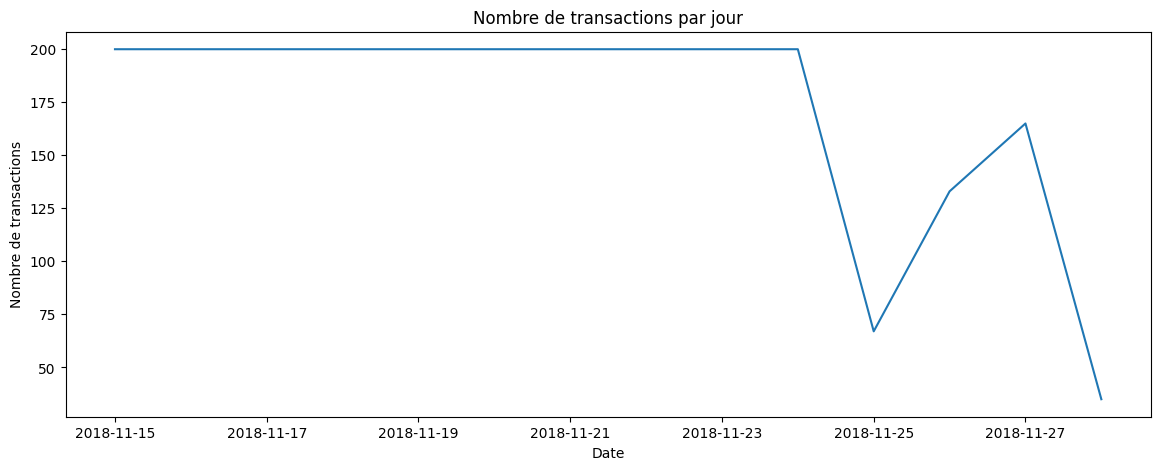

In [23]:
# Serie temporelle : activite par jour (matplotlib)
plt.figure(figsize=(14, 5))
transactions_per_day.plot()
plt.title('Nombre de transactions par jour')
plt.xlabel('Date')
plt.ylabel('Nombre de transactions')
plt.show()

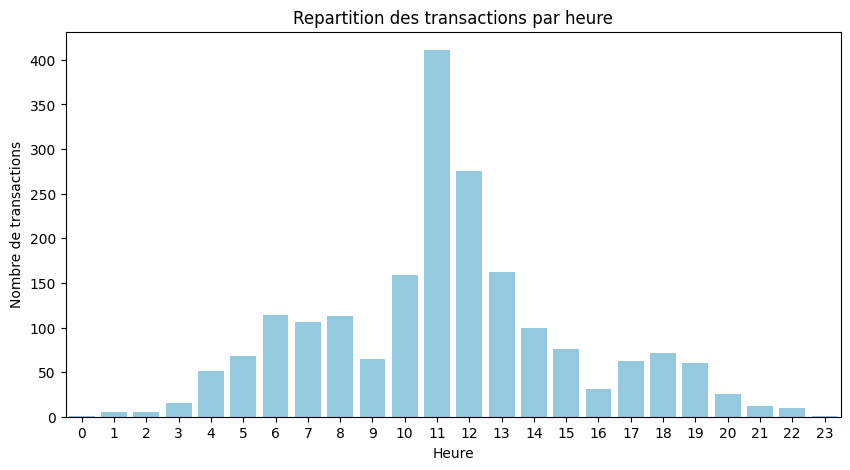

In [24]:
# Histogramme des effectifs par heure de la journee (seaborn)
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Hour', color='skyblue')
plt.title('Repartition des transactions par heure')
plt.xlabel('Heure')
plt.ylabel('Nombre de transactions')
plt.show()

In [33]:
# Tableau agrege pour le camembert par canal
channel_counts = df['ChannelId'].value_counts().reset_index()
channel_counts.columns = ['ChannelId', 'Count']

In [26]:
# Part du trafic par canal (plotly)
fig = px.pie(channel_counts, names='ChannelId', values='Count',
             title='Repartition des transactions par canal')
fig.show(renderer='browser')

In [28]:
# Rentabilite moyenne par categorie (tri croissant pour le barh)
rentabilite = df.groupby('ProductCategory')['TauxRentabilite'].mean().sort_values()

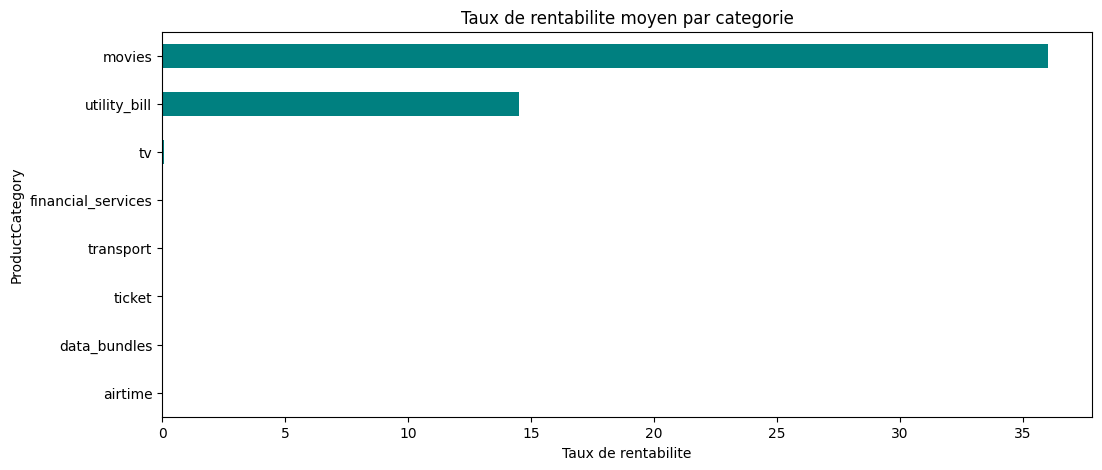

In [29]:
# Comparaison des rentabilites moyennes entre categories (barres horizontales)
plt.figure(figsize=(12, 5))
rentabilite.plot(kind='barh', color='teal')
plt.title('Taux de rentabilite moyen par categorie')
plt.xlabel('Taux de rentabilite')
plt.show()

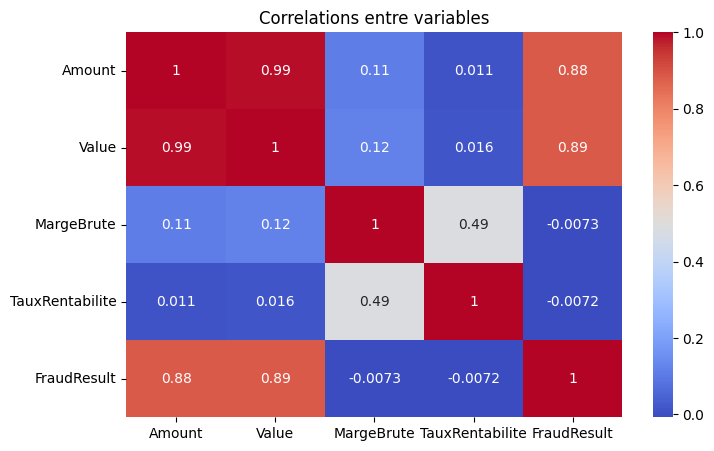

In [30]:
# Matrice de correlation entre variables numeriques (dont la cible fraude)
plt.figure(figsize=(8, 5))
sns.heatmap(df[['Amount', 'Value', 'MargeBrute', 'TauxRentabilite', 'FraudResult']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlations entre variables')
plt.show()

In [31]:
# Chiffre d'affaires cumule par categorie (somme des Value)
revenue_per_category = df.groupby('ProductCategory')['Value'].sum().sort_values(ascending=False).reset_index()

In [29]:
# Barres : contribution au revenu par categorie (plotly)
fig = px.bar(revenue_per_category,
             x='ProductCategory', y='Value',
             title='Revenu total par categorie de produit',
             color='Value')
fig.show(renderer='browser')

In [32]:
# Fraude en pourcentage par categorie (plotly)
fraud_plot = df.groupby('ProductCategory')['FraudResult'].mean().sort_values(ascending=False).reset_index()
fraud_plot['FraudResult'] = fraud_plot['FraudResult'] * 100

fig = px.bar(fraud_plot, x='ProductCategory', y='FraudResult', color='FraudResult',
             title='Taux de fraude par categorie (%)')
fig.show(renderer='browser')

## 5. Conclusion

En suivant le fil habituel d'un mini-projet d'analyse — donnees brutes, preparation, chiffres cles, puis figures — on obtient une lecture coherente du jeu de donnees.

Points saillants :

- les cas de fraude restent peu nombreux par rapport au volume total ;
- la categorie `financial_services` domine en nombre de transactions ;
- `ChannelId_3` et `ChannelId_2` expliquent l'essentiel du trafic observe ;
- les visualisations confirment des variations dans le temps et des profils differents selon le canal et la categorie de produit.

Une **application Streamlit** peut ensuite reprendre ces elements sous forme de tableau de bord filtrable pour un usage plus interactif au quotidien.
